[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/raulpg14/Quantum-Internet-Network-Simulator/blob/master/notebooks/02_evolution_analysis.ipynb)

# Network evolution analysis — average path length and diameter
Analyses how average shortest path length and diameter scale with number of nodes N at fixed density.
Compatible with local Jupyter and Google Colab.

In [10]:
import sys
try:
    import qcn
except ImportError:
    import subprocess
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet',
        'git+https://github.com/raulpg14/Quantum-Internet-Network-Simulator.git'
    ])
    import qcn

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from qcn.engine.simulation import run_simulation
from qcn.engine.config import (
    NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI,
    SIM_MODE_EVOLUTION, STYLE_MAP,
    DEFAULT_DENSITY_COEFF_EVOLUTION,
)
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [12]:
import os

# Detect CI environment correctly
IN_CI = os.environ.get("CI", "false").lower() in ("true", "1", "yes")

# --- Simulation parameters ---
INITIAL_NODES       = 100  if IN_CI else 500
DENSITY_COEFF       = DEFAULT_DENSITY_COEFF_EVOLUTION
MC_REPS             = 1    if IN_CI else 3
STEPS               = 3    if IN_CI else 8
NODE_INCREMENT      = 50   if IN_CI else 200
SEED                = 42
APPROX_PATH_SAMPLES = 0    if IN_CI else 200
# -----------------------------

print(f"IN_CI: {IN_CI}")
print(f"INITIAL_NODES={INITIAL_NODES} STEPS={STEPS} MC_REPS={MC_REPS} APPROX={APPROX_PATH_SAMPLES}")

IN_CI: False
INITIAL_NODES=500 STEPS=8 MC_REPS=3 APPROX=200


In [13]:
results = {}
for net_type in [NETWORK_TYPE_OFBQI, NETWORK_TYPE_SBQI]:
    res = run_simulation({
        'nodes':               INITIAL_NODES,
        'radius':              DENSITY_COEFF,
        'type':                net_type,
        'mc_iter':             MC_REPS,
        'nets_per_mc':         STEPS,
        'rad_incr':            NODE_INCREMENT,
        'sim_mode':            SIM_MODE_EVOLUTION,
        'seed':                SEED,
        'approx_path_samples': APPROX_PATH_SAMPLES,
    })
    if res.get('success'):
        results[net_type] = res
        print(f"{net_type}: OK")
    else:
        print(f"{net_type}: ERROR — {res.get('error')}")

OFBQI: OK
SBQI: OK


In [14]:
import time
from qcn.engine.results_store import save_run, get_runs

# Save results to the database
for net_type, res in results.items():
    run_id = save_run(res, duration_s=0.0)
    print(f"{net_type}: saved as run_id={run_id}")

# Show all runs in the database
runs = get_runs()
print(f"\nTotal runs in database: {len(runs)}")

OFBQI: saved as run_id=25
SBQI: saved as run_id=26

Total runs in database: 26


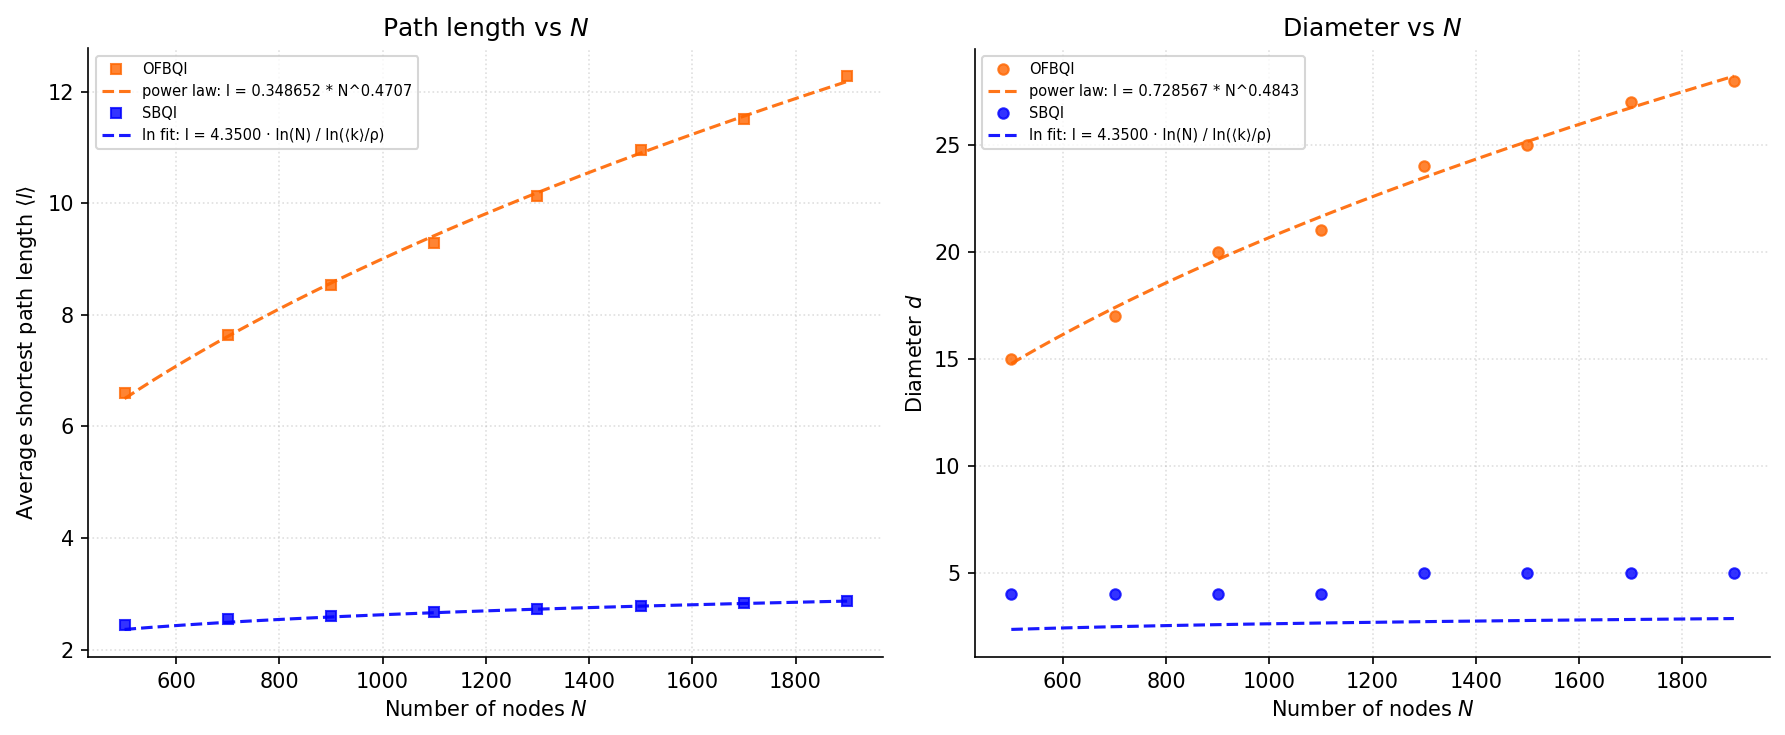

In [18]:
import numpy as np
from qcn.engine.math_util import log_func, power_func

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def compute_fit_curve(x_fit, fp):
    """Evaluate a fit dict over x_fit. Returns (y_fit, label) or (None, None)."""
    if fp is None:
        return None, None
    fit_type = fp.get('type')
    if fit_type == 'logarithmic':
        if fp.get('analytic'):
            denom = np.log(fp['mean_degree'] / fp['density'])
            y = fp['c_rho'] * np.log(x_fit) / denom
        else:
            y = log_func(x_fit, fp['a'], fp['b'])
        return y, rf"ln fit: {fp['formula']}"
    elif fit_type == 'powerlaw':
        y = power_func(x_fit, fp['b'], fp['alpha'])
        return y, rf"power law: {fp['formula']}"
    return None, None

for net_type, res in results.items():
    style   = STYLE_MAP[net_type]
    x_nodes = np.array(res['x_nodes'])
    y_path  = np.array(res['y_path'])
    y_diam  = np.array(res['y_diameter'])
    fp      = res.get('fit_params')
    fp_diam = res.get('fit_params_diam')
    x_fit   = np.linspace(x_nodes.min(), x_nodes.max(), 300)

    # Simulation points
    ax1.plot(x_nodes, y_path,
             color=style['color'], marker='s', linestyle='',
             markersize=5, alpha=0.8, label=style['label'])
    ax2.plot(x_nodes, y_diam,
             color=style['color'], marker='o', linestyle='',
             markersize=5, alpha=0.8, label=style['label'])

    # Path length fit
    y_fit, fit_label = compute_fit_curve(x_fit, fp)
    if y_fit is not None:
        ax1.plot(x_fit, y_fit, color=style['color'], linestyle='--',
                 linewidth=1.5, alpha=0.9, label=fit_label)

    # Diameter fit
    y_fit_d, diam_label = compute_fit_curve(x_fit, fp_diam)
    if y_fit_d is not None:
        ax2.plot(x_fit, y_fit_d, color=style['color'], linestyle='--',
                 linewidth=1.5, alpha=0.9, label=diam_label)

ax1.set_xlabel('Number of nodes $N$')
ax1.set_ylabel('Average shortest path length $\\langle l \\rangle$')
ax1.set_title('Path length vs $N$')
ax1.legend(fontsize=7)
ax1.grid(True, linestyle=':', alpha=0.4)

ax2.set_xlabel('Number of nodes $N$')
ax2.set_ylabel('Diameter $d$')
ax2.set_title('Diameter vs $N$')
ax2.legend(fontsize=7)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('evolution_analysis.pdf', bbox_inches='tight')
plt.show()

In [16]:
for net_type, res in results.items():
    print(f"{net_type} keys: {list(res.keys())}")
    print(f"  fit_params: {res.get('fit_params')}")
    print(f"  fit_params_diam: {res.get('fit_params_diam')}")

OFBQI keys: ['success', 'mode', 'G', 'pos', 'x_nodes', 'y_path', 'y_diameter', 'y_clustering', 'y_mean_degree', 'y_ng_ratio', 'type', 'final_radius', 'final_n', 'density_val', 'density_coeff', 'fit_params', 'fit_params_diam', 'seed']
  fit_params: {'type': 'powerlaw', 'b': np.float64(0.3486515919893557), 'alpha': np.float64(0.47072358043897294), 'formula': 'l = 0.348652 * N^0.4707'}
  fit_params_diam: {'type': 'powerlaw', 'b': np.float64(0.7285671870134747), 'alpha': np.float64(0.48427629388994564), 'formula': 'l = 0.728567 * N^0.4843'}
SBQI keys: ['success', 'mode', 'G', 'pos', 'x_nodes', 'y_path', 'y_diameter', 'y_clustering', 'y_mean_degree', 'y_ng_ratio', 'type', 'final_radius', 'final_n', 'density_val', 'density_coeff', 'fit_params', 'fit_params_diam', 'seed']
  fit_params: {'type': 'logarithmic', 'analytic': True, 'c_rho': 4.349968366087242, 'density': 0.0002, 'mean_degree': 18.61303167627007, 'residual': 0.001385796648564492, 'formula': 'l = 4.3500 · ln(N) / ln(⟨k⟩/ρ)'}
  fit_pa

In [17]:
for net_type, res in results.items():
    fp = res.get('fit_params')
    if fp:
        fit_type = fp.get('type', 'unknown')
        print(f"{net_type} ({fit_type}): {fp['formula']}")
    else:
        print(f"{net_type}: fit not available")

OFBQI (powerlaw): l = 0.348652 * N^0.4707
SBQI (logarithmic): l = 4.3500 · ln(N) / ln(⟨k⟩/ρ)
